<a href="https://colab.research.google.com/github/bhsmlc/bhsmlc-resources/blob/main/projects/mnist-hadwritten-digits/%5B5%5D_tensorflow_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import models, layers

# Load the dataset
data = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

# Normalize pixel values (helps the model learn faster)
x_train, x_test = x_train/255, x_test/255

# Reshape to match expected format, adding a color channel
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Define the architecture
layer0 = layers.Input((28, 28, 1))                     # Tells the model the shape of each image (helps it learn faster)
layer1 = layers.Conv2D(64, (3, 3), activation="relu")  # Looks for patterns (edges, curves, loops) using 64 filters
layer2 = layers.MaxPooling2D((2, 2))                   # Shrink the image to highlight the most important features
layer3 = layers.Conv2D(64, (3, 3), activation="relu")  # Look for more complex patterns
layer4 = layers.MaxPooling2D((2, 2))                   # Shrink again
layer5 = layers.Flatten()                              # Turn the 2d image into a 1d array for the final layers
layer6 = layers.Dense(64, activation="relu")           # A hidden layer of neurons to process the features
layer7 = layers.Dense(10, activation="softmax")        # Output - 10 neurons, 1 for each class 0-9

# Build the model
model = models.Sequential()
model.add(layer0)
model.add(layer1)
model.add(layer2)
model.add(layer3)
model.add(layer4)
model.add(layer5)
model.add(layer6)
model.add(layer7)

# Configure how the model learns
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the model on the training dataset (and additionally calculate accuracy and compare with test data)
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)

# Run the trained model on the test dataset
model.evaluate(x_test, y_test, verbose=2)

# Save the model so we don't have to build it again
model.save("mnist_cnn.keras")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 46ms/step - accuracy: 0.9564 - loss: 0.1450 - val_accuracy: 0.9824 - val_loss: 0.0510
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.9842 - loss: 0.0505 - val_accuracy: 0.9781 - val_loss: 0.0621
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 45ms/step - accuracy: 0.9885 - loss: 0.0355 - val_accuracy: 0.9865 - val_loss: 0.0467
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9915 - loss: 0.0266 - val_accuracy: 0.9856 - val_loss: 0.0532
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9862 - val_loss: 0.0527
313/313 - 3s - 11ms/step - accuracy: 0.9862 - loss: 0.0527


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
incorrect: 138
total: 10000
accuracy: 98.62


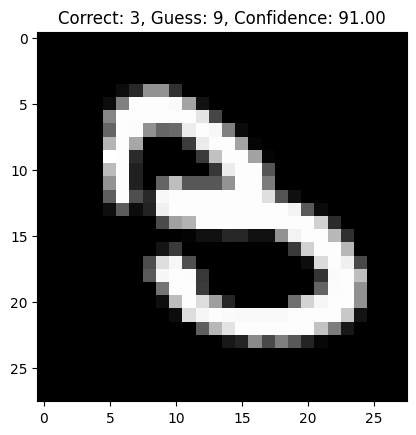

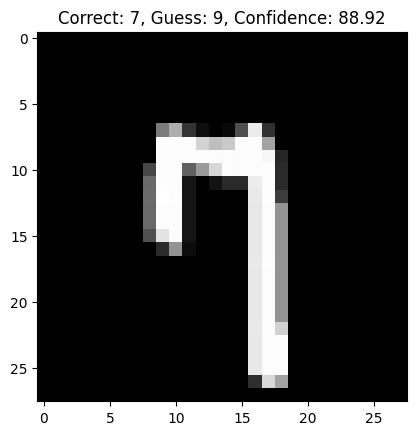

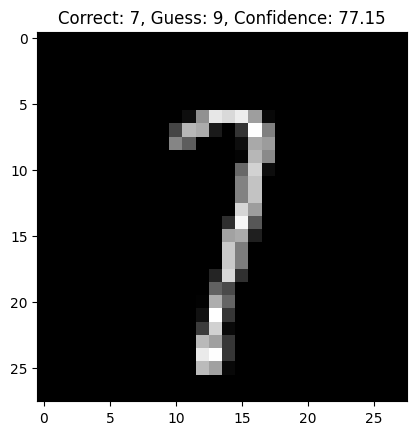

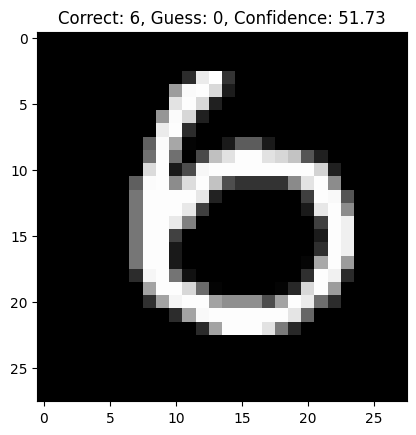

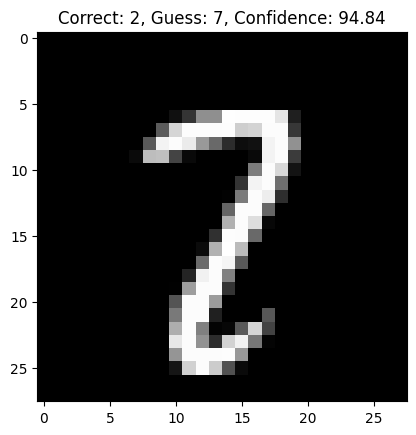

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the model we saved previously
model2 = models.load_model("mnist_cnn.keras")

# For each image, returns the confidence score for each of the classes 0-9
# Example: [0.002, 0.08, 78.23, 0.29, 10.87, 1.174, 2.451, 0.893, 4.210, 1.800]
predictions = model2.predict(x_test)

# For each image, picks the index of the highest value in the array of confidences
# In the example above, it would pick "2" because it has the highest confidence,
# That index corresponds with the number 2 itself, so the prediction for this image would be "2"
predictions_values = np.argmax(predictions, axis=1)

# Gets the specific indexes of the places where the model's predictions don't match the correct values we were provided
incorrect_indexes = np.where(predictions_values != y_test)[0]

# Change it from the format tensorflow wants to the format matplotlib wants
x_test = x_test.reshape(-1, 28, 28)

# Print some metrics: the total incorrect, the total images, and the accuracy
print(f"incorrect: {len(incorrect_indexes)}\ntotal: {len(y_test)}\naccuracy: {((len(y_test)-len(incorrect_indexes))/len(y_test))*100:.2f}")

# Show the images it got wrong
# Most of the time its because the numbers just look really weird
# Fun fact: even for humans, its hard to get over a 98% on this dataset
# You can load more images by adjusting this number, try it out!
                           👇
for i in incorrect_indexes[:5]:
  # Prepare the image
  plt.imshow(x_test[i], cmap="gray")
  # Set the title to useful information for us
  plt.title(f"Correct: {y_test[i]}, Guess: {predictions_values[i]}, Confidence: {max(predictions[i])*100:.2f}")
  # Make the image pop up
  plt.show()

# Thank you for reading and make sure to try stuff out!
